Źródło danych - https://archive.ics.uci.edu/dataset/105/congressional+voting+records

**Opis zbioru**:

Zbiór zawiera rekordy głosowań Kongresu USA z 1984 roku. Jest to zbiór wielowymiarowy z dziedziny nauk społecznych. Głównym zadaniem jest klasyfikacja, czyli rozpoznanie, czy dany kongresmen jest Republikaninem czy Demokratą.

    Liczba instancji (wierszy): 435 (tylu jest kongresmenów).

    Braki danych: Występują.

**Cechy:**

    Liczba cech: 16.

    Typ cech: Kategoryczne.

    Opis: Każda cecha to wynik jednego z 16 kluczowych głosowań w Izbie Reprezentantów.

    Wartości: Oryginalne 9 typów głosów zostało uproszczone do trzech kategorii:

        yea (głos za),

        nay (głos przeciw),

        unknown (stanowisko nieznane/wstrzymanie się).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
column_names = [
    "party",
    "handicapped-infants",
    "water-project-cost-sharing",
    "adoption-of-the-budget-resolution",
    "physician-fee-freeze",
    "el-salvador-aid",
    "religious-groups-in-schools",
    "anti-satellite-test-ban",
    "aid-to-nicaraguan-contras",
    "mx-missile",
    "immigration",
    "synfuels-corporation-cutback",
    "education-spending",
    "superfund-right-to-sue",
    "crime",
    "duty-free-exports",
    "export-administration-act-south-africa"
]

In [3]:
df = pd.read_csv('congressional+voting+records/house-votes-84.data', header=None, names=column_names, na_values='?')

In [4]:
df.describe()

,party,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
count,435,423,387,424,424,420,424,421,420,413,428,414,404,410,418,407,331
unique,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,democrat,n,y,y,n,y,y,y,y,y,y,n,n,y,y,n,y
freq,267,236,195,253,247,212,272,239,242,207,216,264,233,209,248,233,269


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   party                                   435 non-null    object
 1   handicapped-infants                     423 non-null    object
 2   water-project-cost-sharing              387 non-null    object
 3   adoption-of-the-budget-resolution       424 non-null    object
 4   physician-fee-freeze                    424 non-null    object
 5   el-salvador-aid                         420 non-null    object
 6   religious-groups-in-schools             424 non-null    object
 7   anti-satellite-test-ban                 421 non-null    object
 8   aid-to-nicaraguan-contras               420 non-null    object
 9   mx-missile                              413 non-null    object
 10  immigration                             428 non-null    object
 11  synfue

In [6]:
df.head()

,party,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
0,republican,n,y,n,y,y,y,n,n,n,y,NaN,y,y,y,n,y
1,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,NaN
2,democrat,NaN,y,y,NaN,y,y,n,n,n,n,y,n,y,y,n,n
3,democrat,n,y,y,n,NaN,y,n,n,n,n,y,n,y,n,n,y
4,democrat,y,y,y,n,y,y,n,n,n,n,y,NaN,y,y,y,y


In [7]:
df.isnull().sum()

party                                       0
handicapped-infants                        12
water-project-cost-sharing                 48
adoption-of-the-budget-resolution          11
physician-fee-freeze                       11
el-salvador-aid                            15
religious-groups-in-schools                11
anti-satellite-test-ban                    14
aid-to-nicaraguan-contras                  15
mx-missile                                 22
immigration                                 7
synfuels-corporation-cutback               21
education-spending                         31
superfund-right-to-sue                     25
crime                                      17
duty-free-exports                          28
export-administration-act-south-africa    104
dtype: int64

In [8]:
df['party'].value_counts()

party
democrat      267
republican    168
Name: count, dtype: int64

W zbiorze występuję 267 demokratów oraz 168 republikanów, nie jest to idealnie zrównoważony zbiór

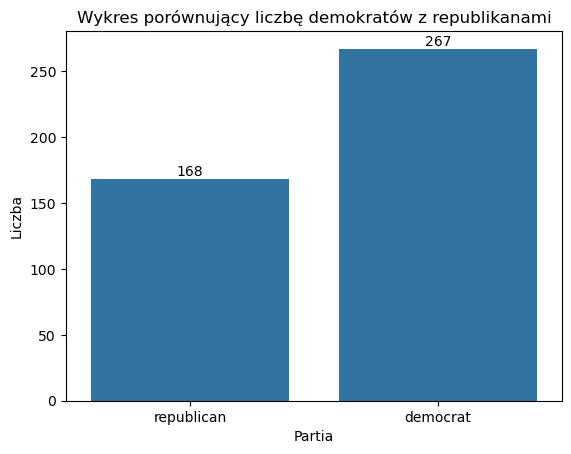

In [9]:
ax = sns.countplot(
    x = df['party'],
    data = df
)
ax.bar_label(ax.containers[0])
plt.title('Wykres porównujący liczbę demokratów z republikanami')
plt.xlabel('Partia')
plt.ylabel('Liczba')
plt.show()

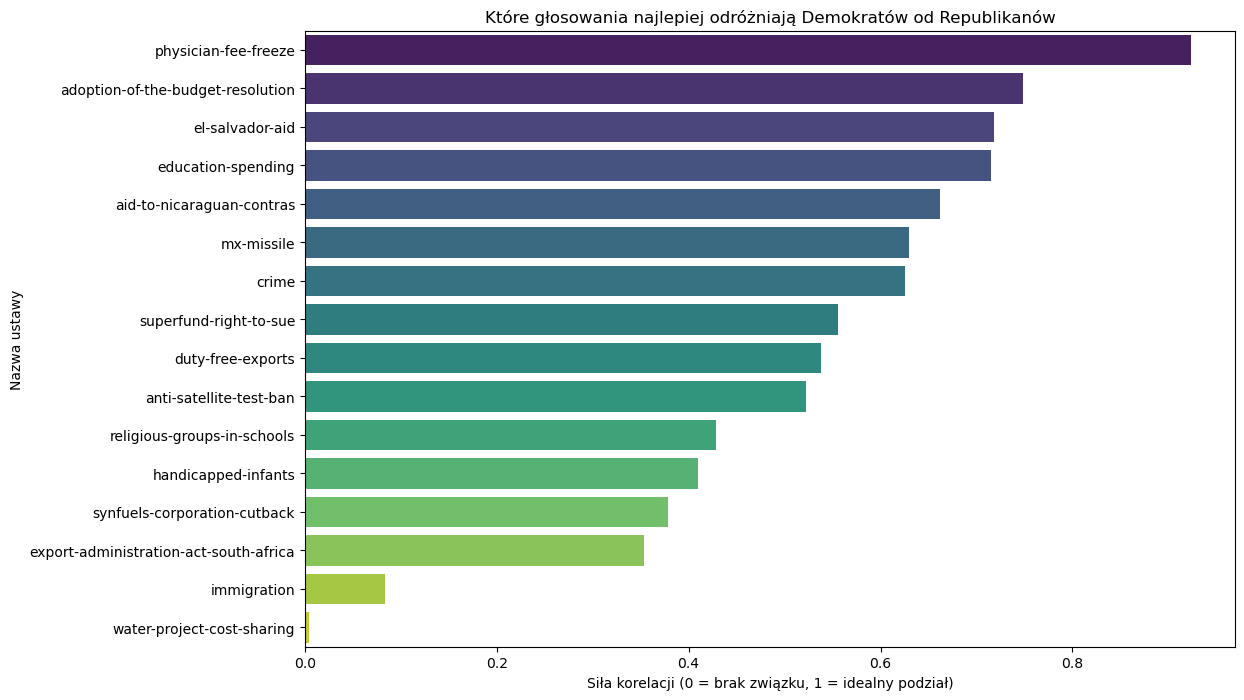

In [10]:
df_numeric = df.copy()

df_numeric['party'] = df_numeric['party'].map({'democrat': 0, 'republican' : 1})

for col in df_numeric.columns[1:]:
    df_numeric[col] = df_numeric[col].map({'y':1, 'n':0})

correlations = df_numeric.corr()['party'].drop('party').abs().sort_values(ascending=False)

plt.figure(figsize = (12,8))    
sns.barplot(x = correlations.values,
            y = correlations.index, 
            palette='viridis', 
            hue =  correlations.index, 
            legend = False)
plt.title('Które głosowania najlepiej odróżniają Demokratów od Republikanów')
plt.xlabel('Siła korelacji (0 = brak związku, 1 = idealny podział)')
plt.ylabel('Nazwa ustawy')
plt.show()

Obliczenie korelacji dla każdego głosowania względem kolumny decydującej, przy większej ilości kolumn pomogłoby ograniczyć cechy, które najlepiej wrzucić do algorytmu

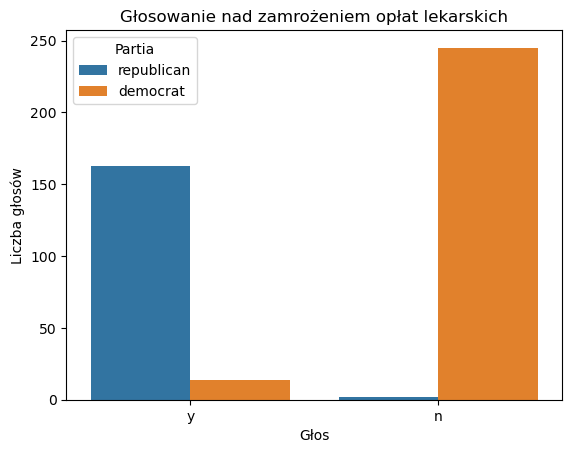

In [11]:
sns.countplot(
    x='physician-fee-freeze',
    hue='party',             
    data=df                  
)
plt.title('Głosowanie nad zamrożeniem opłat lekarskich')
plt.xlabel('Głos')
plt.ylabel('Liczba głosów')
plt.legend(title='Partia') 
plt.show()

Dla "najlepszej" cechy widać jasny podział oddzielajacy od siebie partie

In [12]:
from sklearn.impute import SimpleImputer

In [13]:
pd.set_option('future.no_silent_downcasting', True)
imputer = SimpleImputer(strategy='most_frequent')
data_array = imputer.fit_transform(df)
df_clean = pd.DataFrame(data_array, columns=df.columns)

Uzupełnienie wszystkich brakujących danych za pomocą SimpleImputera z użyciem strategii najczęściej występującej wartości

In [14]:
df_model = df_clean.copy()
df_model['party'] = df_model['party'].map({'democrat': 0, 'republican' : 1})

for col in df_model.columns[1:]:
    df_model[col] = df_model[col].map({'y':1, 'n':0})

    
X = df_model.drop('party', axis = 1)
y = df_model['party']


Przekształcenie danych, zmieniając wartości kategoryczne ('democrat', 'republican', 'y', 'n') na wartości numeryczne (0, 1), aby danych można było odpowiednio użyć w algorytmie

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

Podzielenie zbioru na podzbiór treningowy oraz testujący w proporcjach 70/30

In [17]:
print(f"Rozmiar zbioru treningowego: {X_train.shape}")
print(f"Rozmiar zbioru testowego: {X_test.shape}")

Rozmiar zbioru treningowego: (304, 16)
Rozmiar zbioru testowego: (131, 16)


In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
tree_model = DecisionTreeClassifier(random_state = 42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
before_upgrade = accuracy_score(y_test, y_pred_tree)
print("Dokładność - Drzewo Decyzyjne:", before_upgrade)

Dokładność - Drzewo Decyzyjne: 0.9236641221374046


Jako pierwszy algorytm użyte zostało Drzewo Decyzyjne

In [20]:
log_model = LogisticRegression(random_state = 42)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
before_upgrade2 = accuracy_score(y_test, y_pred_log)
print("Dokładność - Regresja Logistyczna:", before_upgrade2)

Dokładność - Regresja Logistyczna: 0.9618320610687023


Jako drugi algorytm użyta Regresja Logistyczna

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        85
           1       0.93      0.85      0.89        46

    accuracy                           0.92       131
   macro avg       0.92      0.91      0.91       131
weighted avg       0.92      0.92      0.92       131



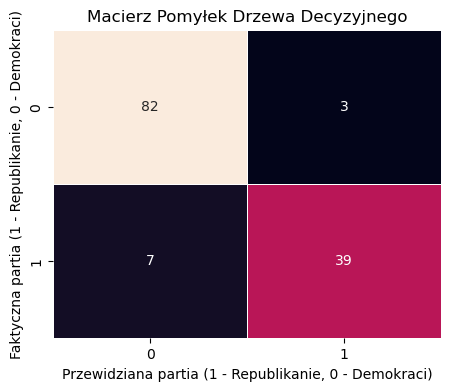

In [21]:
raport_tree = classification_report(y_test, y_pred_tree)
print(raport_tree)
cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize = (5,4))

sns.heatmap (
    data = cm,
    annot = True,
    fmt = 'd',
    linewidths=0.5,
    cbar = False
)
plt.title('Macierz Pomyłek Drzewa Decyzyjnego')
plt.xlabel('Przewidziana partia (1 - Republikanie, 0 - Demokraci)')
plt.ylabel('Faktyczna partia (1 - Republikanie, 0 - Demokraci)')
plt.show()

Dzrzewo decyzyjne przypisało aż 7 Republikanów na 46 jako demokratów, za to tylko 3 demokratów jako republikanów na 85 łącznie

              precision    recall  f1-score   support

           0       0.98      0.96      0.97        85
           1       0.94      0.96      0.95        46

    accuracy                           0.96       131
   macro avg       0.96      0.96      0.96       131
weighted avg       0.96      0.96      0.96       131



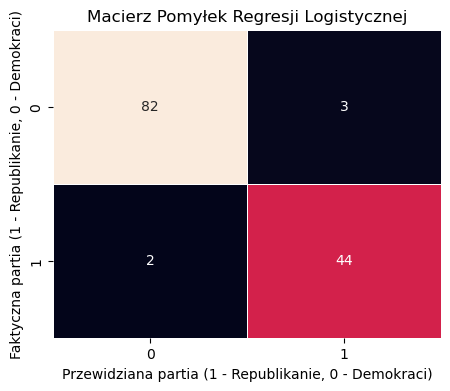

In [22]:
raport_log = classification_report(y_test, y_pred_log)
print(raport_log)

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize = (5,4))

sns.heatmap(
    data = cm,
    annot = True,
    linewidth = 0.5,
    cbar = False
)

plt.title('Macierz Pomyłek Regresji Logistycznej')
plt.xlabel('Przewidziana partia (1 - Republikanie, 0 - Demokraci)')
plt.ylabel('Faktyczna partia (1 - Republikanie, 0 - Demokraci)')
plt.show()

Regresja logistyczna popełniła minimalne błędy, przypisując tylko 2 Republikanów jako Demokratów oraz tylko 3 Demokratów jako Republikanów 

In [23]:
sample_data = X_test.iloc[:5]
true_labels = y_test.iloc[:5]
predictions = tree_model.predict(sample_data)

results = pd.DataFrame({
    'Prawdziwa Partia': true_labels.map({0: 'Demokrata', 1: 'Republikanin'}),
    'Przewidywanie Modelu': [('Republikanin' if x==1 else 'Demokrata') for x in predictions]
})

print("Przykładowe wyniki klasyfikacji:")
print(results)

Przykładowe wyniki klasyfikacji:
    Prawdziwa Partia Przewidywanie Modelu
280        Demokrata            Demokrata
78         Demokrata            Demokrata
113     Republikanin         Republikanin
253     Republikanin         Republikanin
324     Republikanin            Demokrata


In [24]:
raw_input = df.iloc[[5]].copy()
display(raw_input)
processed_array = imputer.transform(raw_input)
processed_df = pd.DataFrame(processed_array, columns=raw_input.columns)
X_sample = processed_df.drop('party', axis=1)
for col in X_sample.columns:
    X_sample[col] = X_sample[col].map({'y': 1, 'n': 0})

prediction = log_model.predict(X_sample)
probability = log_model.predict_proba(X_sample)
wynik_tekst = "Republikanin" if prediction[0] == 1 else "Demokrata"
pewnosc = probability[0][prediction[0]] * 100
prawdziwa_partia = raw_input['party'].values[0]

print(f"Model przewiduje: {wynik_tekst}")
print(f"Pewność decyzji:  {pewnosc:.2f}%")
print(f"Rzeczywista partia: {prawdziwa_partia}")


,party,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
5,democrat,n,y,y,n,y,y,n,n,n,n,n,n,y,y,y,y


Model przewiduje: Demokrata
Pewność decyzji:  96.96%
Rzeczywista partia: democrat


Dla wybranego surowego wiersza, algorytm poprawnie przewidział jego przynależność do partii demokratów, a pewność tego wyboru wynosiła 97%

In [25]:
upgraded_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
upgraded_tree.fit(X_train, y_train)
y_pred_upgraded = upgraded_tree.predict(X_test)

print("Dokładność Drzewa przed zmianą:", round(accuracy_score(y_test, y_pred_tree),2))
print("Dokładność Drzewa po ograniczeniu (max_depth=3):", round(accuracy_score(y_test, y_pred_upgraded),2))

Dokładność Drzewa przed zmianą: 0.92
Dokładność Drzewa po ograniczeniu (max_depth=3): 0.95


Dla Drzewa Decyzyjnego ograniczona została jego głębokość na 3, co poprawiło dokładność z 0.92 na 0.95

**Próba poprawienia wyniku modelu - usuniecie 2 najmniej ważnych cech według korelacji** 

In [26]:
df_upgraded = df_clean.copy()
df_upgraded = df_upgraded.drop(['water-project-cost-sharing','immigration'], axis = 1)
df_upgraded['party'] = df_upgraded['party'].map({'democrat': 0, 'republican' : 1})

for col in df_upgraded.columns[1:]:
    df_upgraded[col] = df_upgraded[col].map({'y':1, 'n':0})

In [27]:
df_upgraded.columns

Index(['party', 'handicapped-infants', 'adoption-of-the-budget-resolution',
       'physician-fee-freeze', 'el-salvador-aid',
       'religious-groups-in-schools', 'anti-satellite-test-ban',
       'aid-to-nicaraguan-contras', 'mx-missile',
       'synfuels-corporation-cutback', 'education-spending',
       'superfund-right-to-sue', 'crime', 'duty-free-exports',
       'export-administration-act-south-africa'],
      dtype='object')

In [28]:
X = df_upgraded.drop('party', axis = 1)
y = df_upgraded['party']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

tree_model2 = DecisionTreeClassifier(random_state = 42)
tree_model2.fit(X_train, y_train)
y_pred_tree2 = tree_model2.predict(X_test)
dokl_upg = accuracy_score(y_test, y_pred_tree2)
print("Dokładność - Drzewo Decyzyjne po wyrzuceniu 2 najmniej skorelowanych cech:", dokl_upg)

Dokładność - Drzewo Decyzyjne po wyrzuceniu 2 najmniej skorelowanych cech: 0.9389312977099237


In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

log_model2 = LogisticRegression(random_state = 42)
log_model2.fit(X_train, y_train)
y_pred_log2 = log_model2.predict(X_test)
dokl_upg2 = accuracy_score(y_test, y_pred_log2)
print("Dokładność - Regresja Logistyczna po wyrzuceniu 2 najmniej skorelowanych cech:", dokl_upg2)

Dokładność - Regresja Logistyczna po wyrzuceniu 2 najmniej skorelowanych cech: 0.9618320610687023


In [30]:
print(f"Dokładość po usunięciu 2 najmniej skorelowanych cech w drzewie decyzyjnym zwiększyła się o {dokl_upg - before_upgrade}")
print(f"Dokładość po usunięciu 2 najmniej skorelowanych cech w regresji logistycznej zwiększyła się o {dokl_upg2 - before_upgrade2}")

Dokładość po usunięciu 2 najmniej skorelowanych cech w drzewie decyzyjnym zwiększyła się o 0.01526717557251911
Dokładość po usunięciu 2 najmniej skorelowanych cech w regresji logistycznej zwiększyła się o 0.0


**Wnioski**

Drzewo Decyzyjne i Regresja Logistyczna osiągnęły zbliżoną precyzję w klasyfikacji Republikanów (0.93 vs 0.94). Różnica w końcowej dokładności (Accuracy) wynika z wyższej precyzji Regresji Logistycznej w rozpoznawaniu Demokratów (0.98 vs 0.92). Najsłabszym punktem algorytmów była czułość (recall) Drzewa Decyzyjnego w identyfikacji Republikanów, wynosząca jedynie 0.85 (przy 46 próbkach). Ostatecznie dokładność modelu Drzewa wyniosła 92%, podczas gdy Regresja Logistyczna osiągnęła 96%.

Oba wytrenowane modele osiągnęły bardzo wysoką dokładność, co świadczy o tym, że sposób głosowania kongresmenów jest ściśle powiązany z ich przynależnością partyjną. Najbardziej znaczącą cechą okazało się głosowanie 'physician-fee-freeze', którego korelacja z partią była bliska 1, co widać na przedstawionym wyżej wykresie

Warto również odnotować, że mimo występowania w zbiorze licznych brakujących danych (oznaczonych jako '?'), zastosowana strategia ich uzupełniania okazała się skuteczna i nie wpłynęła negatywnie na zdolności predykcyjne modeli.